In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import math
from iminuit import Minuit
from iminuit.cost import LeastSquares
from fit import fit, calc_mean_dev

In [21]:
# funzione angolo di minima deviazione
def indice_rifrazione (theta, alpha):
    return np.sin((theta + alpha) / 2) / np.sin(alpha / 2)

# funzione incertezza deviazione minima
def deviazione_n (theta, alpha, sigma_theta, sigma_alpha):
    A = sigma_theta * np.cos((theta + alpha) / 2) / np.sin(alpha / 2)
    B = np.cos((theta + alpha) / 2)/np.sin((alpha) / 2) 
    C = np.sin((theta + alpha)/2) * np.cos(alpha / 2)/(np.sin(alpha / 2))**2
    return 0.5 * (A**2 + (sigma_alpha * (B - C))**2)**0.5

# funzione di Cauchy
def cauchy (x, A, B):
    return A + B / x**2

# funzione per il grafico della legge di Cauchy
def func(x, A, B):
    return A + B * x

# funzione di Cauchy inversa
def cauchy_inversa (n, A, B):
    return np.sqrt(B / (n - A))

# funzione errore delle lambda ignote
def errore_lambda (n, A, B, sigma_n, sigma_A, sigma_B, cov_AB):
    a = sigma_B**2 * (n - A)**2
    b = B**2 * (sigma_n**2 + sigma_A**2)
    c = (n - A) * cov_AB
    return (1/4*(n - A)**4) * ((n-A)/B) * (a + b - 2 * B * c)

# funzione per il passo del reticolo
def passo_reticolo (lambda_val, theta, n):
    return n * lambda_val / np.sin(theta)

# funzione per l'errore del passo del reticolo
def errore_passo_reticolo (lambda_val, theta, sigma_lambda, sigma_theta, n):
    a = sigma_lambda * (n / np.sin(theta))
    b = sigma_theta * np.cos(theta) * n * lambda_val/ (np.sin(theta))**2
    return (a**2 + b**2)**0.5

# funzione lambda doppietto del sodio
def lambda_doppietto (theta, n, d):
    return d * np.sin(theta) / n

# funzione errore lambda doppietto del sodio
def errore_lambda_doppietto (theta, n, d, sigma_theta, sigma_d):
    a = sigma_theta * d * np.cos(theta) / n
    b = sigma_d * np.sin(theta) / n
    return (a**2 + b**2)**0.5

# funzione per il t-test
def t_test (valore_teorico, valore_sperimentale, sigma_sperimentale, N) :
    if (valore_teorico - valore_sperimentale) < 0 :
        return (valore_sperimentale - valore_teorico) / (sigma_sperimentale/math.sqrt(N))
    else :
        return (valore_teorico - valore_sperimentale) / (sigma_sperimentale/math.sqrt(N))

CARATTERIZZAZIONE PRISMA (Hg)

In [3]:
# definisco la lista per l'angolo al vertice del prisma
df = pd.read_excel(r"C:\Users\NB05\Desktop\lab 2\dati_prisma.xlsx", sheet_name="Foglio1")
alpha_1_list = df["alpha_1 (gradi)"].dropna().tolist()
alpha_2_list = df["alpha_2 (gradi)"].dropna().tolist()
alpha = np.mean(alpha_1_list) - np.mean(alpha_2_list)
dev_alpha = np.sqrt(np.var(alpha_1_list) + np.var(alpha_2_list))
print("alpha = ", alpha, "+/-", dev_alpha, "gradi")

# definiamo l'angolo di minima deviazione per ciascuna riga spettrale del Hg
theta_0_list = df["theta_zero"].dropna().tolist()
theta_giallo_list = df["theta_giallo"].dropna().tolist()
theta_verde_list = df["theta_verde"].dropna().tolist()
theta_ciano_list = df["theta_azzurro"].dropna().tolist()
theta_blu_list = df["theta_blu"].dropna().tolist()
theta_viola_list = df["theta_viola"].dropna().tolist()

# calcoliamo la media e la deviazione standard per ciascuna lista di angoli
theta_0_mean , theta_0_std = calc_mean_dev(theta_0_list)
theta_giallo_mean , theta_giallo_std = calc_mean_dev(theta_giallo_list)
theta_verde_mean , theta_verde_std = calc_mean_dev(theta_verde_list)
theta_ciano_mean , theta_ciano_std = calc_mean_dev(theta_ciano_list)
theta_blu_mean , theta_blu_std = calc_mean_dev(theta_blu_list)
theta_viola_mean , theta_viola_std = calc_mean_dev(theta_viola_list)
print("theta_0 = ", theta_0_mean, " ± ", theta_0_std, "gradi")
print("theta_giallo = ", theta_giallo_mean, " ± ", theta_giallo_std, "gradi")
print("theta_verde = ", theta_verde_mean, " ± ", theta_verde_std, "gradi")
print("theta_ciano = ", theta_ciano_mean, " ± ", theta_ciano_std, "gradi")
print("theta_blu = ", theta_blu_mean, " ± ", theta_blu_std, "gradi")
print("theta_viola = ", theta_viola_mean, " ± ", theta_viola_std, "gradi")
  

alpha =  61.13866666666664 +/- 0.03433818735913763 gradi
theta_0 =  103.419  ±  0.0208486610281474 gradi
theta_giallo =  151.5413333333333  ±  0.027353650985229565 gradi
theta_verde =  152.458  ±  0.07206016005163292 gradi
theta_ciano =  152.39133333333334  ±  0.013474255287599888 gradi
theta_blu =  153.46366666666668  ±  0.028110891523075873 gradi
theta_viola =  154.508  ±  0.013880441875768002 gradi


In [4]:
# troviamo gli angoli di minima deviazione per ciascuna riga spettrale del Hg
theta_dev = [0] * 5
theta_dev[0] = theta_giallo_mean - theta_0_mean
theta_dev[1] = theta_verde_mean - theta_0_mean
theta_dev[2] = theta_ciano_mean - theta_0_mean
theta_dev[3] = theta_blu_mean - theta_0_mean
theta_dev[4] = theta_viola_mean - theta_0_mean

std_theta_dev = [0] * 5
std_theta_dev[0] = np.sqrt(np.var(theta_giallo_list) + np.var(theta_0_list))
std_theta_dev[1] = np.sqrt(np.var(theta_verde_list) + np.var(theta_0_list))
std_theta_dev[2] = np.sqrt(np.var(theta_ciano_list) + np.var(theta_0_list))
std_theta_dev[3] = np.sqrt(np.var(theta_blu_list) + np.var(theta_0_list))
std_theta_dev[4] = np.sqrt(np.var(theta_viola_list) + np.var(theta_0_list))

colors = ["giallo","verde","ciano","blu","viola"]
for i in range (5):
    print("theta dev min",colors[i]," = ", theta_dev[i], " ± ", std_theta_dev[i], " gradi")


theta dev min giallo  =  48.122333333333316  ±  0.03439315177311237  gradi
theta dev min verde  =  49.039  ±  0.07501555394272273  gradi
theta dev min ciano  =  48.97233333333334  ±  0.024823823682543465  gradi
theta dev min blu  =  50.044666666666686  ±  0.03499841266241558  gradi
theta dev min viola  =  51.08900000000001  ±  0.025046623192222263  gradi


In [5]:
# calcoliamo gli indici di rifrazione per ciascuna riga spettrale del Hg
for i in range(5):
    theta_dev[i] = math.radians(theta_dev[i])
    std_theta_dev[i] = math.radians(std_theta_dev[i])

alpha = math.radians(alpha)
dev_alpha = math.radians(dev_alpha)
print("alpha in radianti = ", alpha, " ± ", dev_alpha)

n = [0] * 5
dev_n = [0] * 5
for i in range(5):
    n[i] = indice_rifrazione(theta_dev[i], alpha)
    dev_n[i] = deviazione_n(theta_dev[i], alpha, std_theta_dev[i], dev_alpha)

for i in range(5):
    print("n",colors[i], " = ", n[i], " ± ", dev_n[i])


alpha in radianti =  1.0670710336126392  ±  0.0005993144285836482
n giallo  =  1.6033564305258765  ±  0.000582925582934782
n verde  =  1.6124096762728706  ±  0.000879674636081383
n ciano  =  1.6117547305423396  ±  0.0005386042419093664
n blu  =  1.622223196739097  ±  0.0005960557338266101
n viola  =  1.632281784210159  ±  0.000554062860790988


In [6]:
# definiamo le lunghezze d'onda per ciascuna riga spettrale del Hg
wave_list = [0] * 5
wave_list[0] = 0.5769    #giallo 0.5769610 oppure 0.5790670
wave_list[1] = 0.5461    #verde 0.5460750
wave_list[2] = 0.4916    #ciano 0.4916068
wave_list[3] = 0.4358    #blu 0.4358335
wave_list[4] = 0.4046    #viola 0.4046565

In [7]:
# facco il fit dei dati
A_fit, B_fit, A_err, B_err, cov_AB = fit(wave_list, n, dev_n, cauchy)

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 64.65 (χ²/ndof = 21.5)     │              Nfcn = 55               │
│ EDM = 1.03e-14 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ A    │  1.5774   │  0.0011   │            │            │         │         │       │
│ 1 │ B    │  8.76e-3  │  0.23e-3  │            │            │         │         │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌───┬───────────────────┐
│   │        A        B │
├───┼───────────────────┤
│ A │ 1.16e-06 -0.24e-6 │
│ B │ -0.24e-6 5.32e-08 │
└───┴───────────────────┘

success of the fit:  True


Valore del fit ki-quadro:  64.64897758563345


Valore del numero di gradi di libertà:  3.0


Valore del fit ki-quadro ridotto:  21.54965919521115


associated p-value:  5.96189764223709e-14


Valori dei parametri di fit con le rispettive incertezze: 
A = 1.57744 +/- 0.00108
B = 0.00876 +/- 0.00023


┌───┬───────────────────┐
│   │        A        B │
├───┼───────────────────┤
│ A │ 1.16e-06 -0.24e-6 │
│ B │ -0.24e-6 5.32e-08 │
└───┴───────────────────┘
covarianza tra A e B:  -2.402644469371244e-07


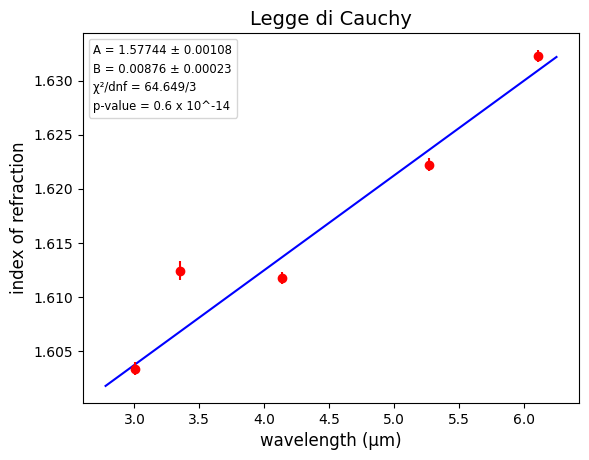

In [8]:
# grafico d'interpolazione lineare della legge di Cauchy per la relazione 
fig, ax = plt.subplots()
x_axis = np.linspace(1/(0.4)**2,1/(0.6)**2, 10000)
y_axis = np.arange(0., x_axis.size)

for i in range(x_axis.size):
    y_axis[i] = func(x_axis[i], A_fit, B_fit)
plt.plot(x_axis, y_axis, color = 'b', label = 'legge di Cauchy')

for i in range(len(wave_list)):
    ax.errorbar(1/(wave_list[i])**2, n[i], xerr = 0, yerr = dev_n[i], color = 'r', linestyle = ':', marker = 'o')     

custom_lines = [Line2D([0], [0], color = 'None', marker = None, lw = 0),
                Line2D([0], [0], color = 'None', marker = None, lw = 0),
                Line2D([0], [0], color = 'None', marker = None, lw = 0),
                Line2D([0], [0], color = 'None', marker = None, lw = 0)
            ]

labels = ['A = 1.57744 ± 0.00108', 'B = 0.00876 ± 0.00023', 'χ²/dnf = 64.649/3', 'p-value = 0.6 x 10^-14']

ax.set_title('Legge di Cauchy', size = 14)
ax.set_ylabel('index of refraction', size = 12)
ax.set_xlabel('wavelength (μm)', size = 12)

ax.legend( fontsize = "small", handles = custom_lines, labels = labels, handlelength=0, handletextpad=0, loc = 'upper left')
plt.show()

In [9]:
# rifittiammo i dati ma normalizzando l'errore sulle n
dev_n_norm = [0] * 5
ki_quadro_rid = 21.54965919521115
for i in range(5):
    dev_n_norm[i] = np.sqrt(ki_quadro_rid) * dev_n[i]
    print("n",colors[i], " = ", n[i], " ± ", dev_n_norm[i])

A_fit_norm, B_fit_norm, A_err_norm, B_err_norm, cov_AB_norm = fit(wave_list, n, dev_n_norm, cauchy)

n giallo  =  1.6033564305258765  ±  0.0027060344349601043
n verde  =  1.6124096762728706  ±  0.004083591330496717
n ciano  =  1.6117547305423396  ±  0.0025002876320585014
n blu  =  1.622223196739097  ±  0.002766986709984006
n viola  =  1.632281784210159  ±  0.0025720490304860476


┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 3 (χ²/ndof = 1.0)          │              Nfcn = 55               │
│ EDM = 1.61e-15 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ A    │   1.577   │   0.005   │            │            │         │         │       │
│ 1 │ B    │  0.0088   │  0.0011   │            │            │         │         │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌───┬───────────────────┐
│   │        A        B │
├───┼───────────────────┤
│ A │  2.5e-05  -5.2e-6 │
│ B │  -5.2e-6 1.15e-06 │
└───┴───────────────────┘

success of the fit:  True


Valore del fit ki-quadro:  3.000000000000113


Valore del numero di gradi di libertà:  3.0


Valore del fit ki-quadro ridotto:  1.0000000000000375


associated p-value:  0.3916251762710711


Valori dei parametri di fit con le rispettive incertezze: 
A = 1.57744 +/- 0.00500
B = 0.00876 +/- 0.00107


┌───┬───────────────────┐
│   │        A        B │
├───┼───────────────────┤
│ A │  2.5e-05  -5.2e-6 │
│ B │  -5.2e-6 1.15e-06 │
└───┴───────────────────┘
covarianza tra A e B:  -5.178497830628713e-06


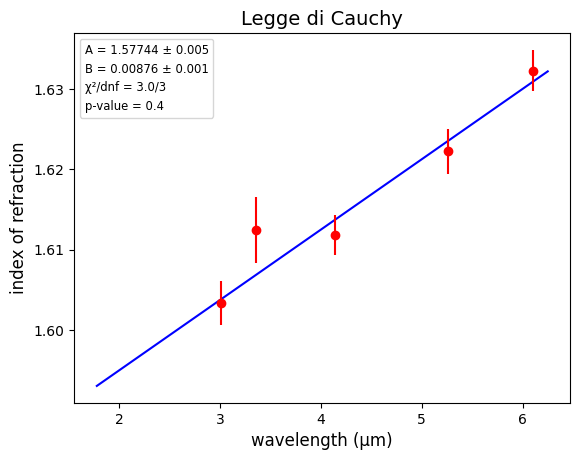

In [10]:
# riplottiamo il grafico d'interpolazione lineare della legge di Cauchy per la relazione con l'errore normalizzato
fig, ax = plt.subplots()
x_axis = np.linspace(1/(0.4)**2,1/(0.75)**2, 10000)
y_axis = np.arange(0., x_axis.size)

for i in range(x_axis.size):
    y_axis[i] = func(x_axis[i], A_fit, B_fit)
plt.plot(x_axis, y_axis, color = 'b', label = 'legge di Cauchy')

for i in range(len(wave_list)):
    ax.errorbar(1/(wave_list[i])**2, n[i], xerr = 0, yerr = dev_n_norm[i], color = 'r', linestyle = ':', marker = 'o')     

custom_lines = [Line2D([0], [0], color = 'None', marker = None, lw = 0),
                Line2D([0], [0], color = 'None', marker = None, lw = 0),
                Line2D([0], [0], color = 'None', marker = None, lw = 0),
                Line2D([0], [0], color = 'None', marker = None, lw = 0)
            ]

labels = ['A = 1.57744 ± 0.005', 'B = 0.00876 ± 0.001', 'χ²/dnf = 3.0/3', 'p-value = 0.4']

ax.set_title('Legge di Cauchy', size = 14)
ax.set_ylabel('index of refraction', size = 12)
ax.set_xlabel('wavelength (μm)', size = 12)

ax.legend( fontsize = "small", handles = custom_lines, labels = labels, handlelength=0, handletextpad=0, loc = 'upper left')
plt.show()

CARATTERIZZAZIONE PRISMA (gas ignoto)

In [11]:
# definisco le liste per gli angoli di ritorno del gas ignoto
df = pd.read_excel(r"C:\Users\NB05\Desktop\lab 2\dati_prisma.xlsx", sheet_name="Foglio2")
list_theta_ign_i = df["theta_ign_i"].dropna().tolist()
list_theta_ign_red = df["theta_ign_rossa"].dropna().tolist()
list_theta_ign_orange = df["theta_ign_orange"].dropna().tolist()
list_theta_ign_verde = df["theta_ign_verde"].dropna().tolist()
list_theta_ign_viola = df["theta_ign_viola_int"].dropna().tolist()
list_theta_ign_viola_low = [154.491, 153.641, 153.425, 153.375]


In [12]:
# calcoliamo media e deviazione standard per ciascuna lista di angoli di ritorno del gas ignoto
theta_ign_i_mean, theta_ign_i_std = calc_mean_dev(list_theta_ign_i)
theta_ign_red_mean, theta_ign_red_std = calc_mean_dev(list_theta_ign_red)
theta_ign_orange_mean, theta_ign_orange_std = calc_mean_dev(list_theta_ign_orange)
theta_ign_verde_mean, theta_ign_verde_std = calc_mean_dev(list_theta_ign_verde)
theta_ign_viola_mean, theta_ign_viola_std = calc_mean_dev(list_theta_ign_viola)
print("theta_ign_i = ", theta_ign_i_mean, "±", theta_ign_i_std, "gradi")
print("theta_ign_red = ", theta_ign_red_mean, "±", theta_ign_red_std, "gradi")
print("theta_ign_orange = ", theta_ign_orange_mean, "±", theta_ign_orange_std, "gradi")
print("theta_ign_verde = ", theta_ign_verde_mean, "±", theta_ign_verde_std, "gradi")
print("theta_ign_viola = ", theta_ign_viola_mean, "±", theta_ign_viola_std, "gradi")

theta_ign_i =  103.53066666666666 ± 0.04385835787572828 gradi
theta_ign_red =  114.38600000000001 ± 0.028437065014985573 gradi
theta_ign_orange =  151.37866666666667 ± 0.014817407180591402 gradi
theta_ign_verde =  152.41366666666667 ± 0.04793282336306949 gradi
theta_ign_viola =  154.38033333333334 ± 0.020757863302579792 gradi


In [13]:
# troviamo gli angoli di minima deviazione per ciascuna riga spettrale del gas ignoto
theta_dev_ign = [0] * 8
theta_dev_ign[0] = theta_ign_viola_mean - theta_ign_i_mean
theta_dev_ign[1] = list_theta_ign_viola[0] - theta_ign_i_mean
theta_dev_ign[2] = list_theta_ign_viola[1] - theta_ign_i_mean
theta_dev_ign[3] = list_theta_ign_viola[2] - theta_ign_i_mean
theta_dev_ign[4] = list_theta_ign_viola_low[3] - theta_ign_i_mean
theta_dev_ign[5] = theta_ign_verde_mean - theta_ign_i_mean
theta_dev_ign[6] = theta_ign_orange_mean - theta_ign_i_mean
theta_dev_ign[7] = theta_ign_red_mean - theta_ign_i_mean

std_theta_dev_ign = [0] * 8
std_theta_dev_ign[0] = np.sqrt(np.var(list_theta_ign_viola) + np.var(list_theta_ign_i))
std_theta_dev_ign[1] = np.sqrt(0.008**2 + np.var(list_theta_ign_i))
std_theta_dev_ign[2] = np.sqrt(0.008**2 + np.var(list_theta_ign_i))
std_theta_dev_ign[3] = np.sqrt(0.008**2 + np.var(list_theta_ign_i))
std_theta_dev_ign[4] = np.sqrt(0.008**2 + np.var(list_theta_ign_i))
std_theta_dev_ign[5] = np.sqrt(np.var(list_theta_ign_verde) + np.var(list_theta_ign_i))
std_theta_dev_ign[6] = np.sqrt(np.var(list_theta_ign_orange) + np.var(list_theta_ign_i))
std_theta_dev_ign[7] = np.sqrt(np.var(list_theta_ign_red) + np.var(list_theta_ign_i))

colors_2 = ["viola","viola low_1","viola low_2","viola low_3","viola low_4","verde","arancione","rosso"]
for i in range (8):
    print("theta dev min ignoto",colors_2[i]," = ", theta_dev_ign[i], " ± ", std_theta_dev_ign[i], " gradi")

theta dev min ignoto viola  =  50.84966666666668  ±  0.04852261786470353  gradi
theta dev min ignoto viola low_1  =  50.84433333333334  ±  0.04458200932613353  gradi
theta dev min ignoto viola low_2  =  50.877333333333326  ±  0.04458200932613353  gradi
theta dev min ignoto viola low_3  =  50.82733333333334  ±  0.04458200932613353  gradi
theta dev min ignoto viola low_4  =  49.84433333333334  ±  0.04458200932613353  gradi
theta dev min ignoto verde  =  48.88300000000001  ±  0.0649700785832269  gradi
theta dev min ignoto arancione  =  47.84800000000001  ±  0.04629374807801696  gradi
theta dev min ignoto rosso  =  10.855333333333348  ±  0.052270663112514396  gradi


In [14]:
# calcoliamo gli indici di rifrazione per ciascuna riga spettrale del gas ignoto
for i in range(8):
    theta_dev_ign[i] = math.radians(theta_dev_ign[i])
    std_theta_dev_ign[i] = math.radians(std_theta_dev_ign[i])

n_ign = [0] * 8
dev_n_ign = [0] * 8
for i in range(8):
    n_ign[i] = indice_rifrazione(theta_dev_ign[i], alpha)
    dev_n_ign[i] = deviazione_n(theta_dev_ign[i], alpha, std_theta_dev_ign[i], dev_alpha)

for i in range(8):
    print("n ignoto",colors_2[i], " = ", n_ign[i], " ± ", dev_n_ign[i])

n ignoto viola  =  1.6299885687685758  ±  0.00068133792303211
n ignoto viola low_1  =  1.629937385449046  ±  0.0006560564442061301
n ignoto viola low_2  =  1.6302540255704756  ±  0.0006561658306379536
n ignoto viola low_3  =  1.6297742150551746  ±  0.0006560001391202859
n ignoto viola low_4  =  1.6202782408186482  ±  0.000652797443764293
n ignoto verde  =  1.6108762480356231  ±  0.000799018258873284
n ignoto arancione  =  1.600627067259175  ±  0.0006584598289658794
n ignoto rosso  =  1.155653283624419  ±  0.0007338653590502166


In [17]:
# calcoliamo la lunghezza d'onda per ciascuna riga spettrale del gas ignoto usando la funzione di Cauchy inversa
wave_ign = [0] * 8
wave_ign_err = [0] * 8

for i in range(8):
    wave_ign[i] = cauchy_inversa(n_ign[i], A_fit_norm, B_fit_norm)
    wave_ign_err[i] = errore_lambda(n_ign[i], A_fit_norm, B_fit_norm, dev_n_ign[i], A_err_norm, B_err_norm, cov_AB_norm)
    wave_ign[i] = wave_ign[i] * 1000
    wave_ign_err[i] = wave_ign_err[i] * 1000
    print("lunghezza d'onda gas ignoto", colors_2[i], " = ", wave_ign[i], " ± ", wave_ign_err[i], " nanometri")

lunghezza d'onda gas ignoto viola  =  408.2680540090979  ±  1.1302150395621362e-10  nanometri
lunghezza d'onda gas ignoto viola low_1  =  408.4670296448637  ±  1.1231966597018082e-10  nanometri
lunghezza d'onda gas ignoto viola low_2  =  407.2407327325155  ±  1.1653324454088533e-10  nanometri
lunghezza d'onda gas ignoto viola low_3  =  409.10330349801876  ±  1.101993873418207e-10  nanometri
lunghezza d'onda gas ignoto viola low_4  =  452.17857278642344  ±  3.268301551857882e-11  nanometri
lunghezza d'onda gas ignoto verde  =  511.81963699713253  ±  7.489692885596755e-12  nanometri
lunghezza d'onda gas ignoto arancione  =  614.6142755189893  ±  8.930831136623305e-13  nanometri
lunghezza d'onda gas ignoto rosso  =  nan  ±  -6.384200824248656e-05  nanometri


C:\Users\NB05\AppData\Local\Temp\ipykernel_5648\3175535987.py:22: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(B / (n - A))


In [24]:
# confronto lunghezze d'onda gas ignoto con i gas nobili e la CO2
lambda_ignoto = [408.26805, 511.81964, 614.61427]
sigma_ignoto = [wave_ign_err[0], wave_ign_err[5], wave_ign_err[6]]

lambda_elio = [388.8648, 501.56783, 587.5621] 
lambda_neon = [408.0148, 511.65032, 614.30627]  
lambda_argon = [415.8590, 516.2285, 614.5441]
lambda_kripton = [427.396943, 557.028944,642.102700 ]
lambda_xeno = [407.88202, 556.6615, 618.2420]

for i in range(3) :
    t_stat_neon = t_test(lambda_neon[i], lambda_ignoto[i], 0.3,N = 3)
    print(f"t-statistic for {lambda_ignoto[i]} nm: {t_stat_neon}")


t-statistic for 408.26805 nm: 1.4621395567229398
t-statistic for 511.81964 nm: 0.9775694757917046
t-statistic for 614.61427 nm: 1.7782388291040054


CARATTERIZZAZIONE RETICOLO (passo d)

In [ ]:
# definisco le liste per gli angoli del secondo massimo d'interferenza del sodio
df = pd.read_excel(r"C:\Users\NB05\Desktop\lab 2\dati_prisma.xlsx", sheet_name="Foglio3")
list_beta_0 = df["beta_zero"].dropna().tolist()
list_beta_sodio_max = df["beta_sodio_max"].dropna().tolist()

In [ ]:
# calcolo media e deviazione standard per gli angoli del secondo massimo d'interferenza del sodio
beta_0_mean, beta_0_std = calc_mean_dev(list_beta_0)
beta_sodio_max_mean, beta_sodio_max_std = calc_mean_dev(list_beta_sodio_max)
print("beta zero = ", beta_0_mean, "±", beta_0_std, "gradi")
print("beta sodio max = ", beta_sodio_max_mean, "±", beta_sodio_max_std, "gradi")

beta zero =  103.46366666666665 ± 0.03412070078738376 gradi
beta sodio max =  82.475 ± 0.013880441875773803 gradi


In [ ]:
# valore angolo di massima interferenza del sodio
beta_sodio_max_int = beta_0_mean - beta_sodio_max_mean
beta_sodio_max_int_std = np.sqrt(np.var(list_beta_sodio_max) + np.var(list_beta_0))
print("beta sodio max = ", beta_sodio_max_int, "±", beta_sodio_max_int_std, "gradi")

beta sodio max =  20.98866666666666 ± 0.03683597275611037 gradi


In [ ]:
# calcoliamo il passo del reticolo 
beta_sodio_max_int = math.radians(beta_sodio_max_int)
beta_sodio_max_int_std = math.radians(beta_sodio_max_int_std)
print("beta sodio max in radianti = ", beta_sodio_max_int, "+/-", beta_sodio_max_int_std)

lambda_sodio = 0.5896   #lunghezza d'onda del sodio in micrometri (0.5890)
lambda_sodio_err = 0.0001
passo_reticolo_val = passo_reticolo(lambda_sodio, beta_sodio_max_int, n =2)
err_passo_reticolo_val = errore_passo_reticolo(lambda_sodio, beta_sodio_max_int, lambda_sodio_err, beta_sodio_max_int_std, n =2)
print("passo del reticolo = ", passo_reticolo_val, " micrometri")
print("errore del passo del reticolo = ", err_passo_reticolo_val, " micrometri")


beta sodio max in radianti =  0.3663213389369164 +/- 0.0006429090077690561
passo del reticolo =  3.2921693362146462  micrometri
errore del passo del reticolo =  0.0055452866426891  micrometri


In [ ]:
# t-test per il passo del reticolo 
passo_reticolo_vero = 3.33 #micrometri
t_stat = t_test(passo_reticolo_vero, passo_reticolo_val, err_passo_reticolo_val, N = 3)
print("t-statistic = ", t_stat)

t-statistic =  11.816274970506056


CARATTERIZZAZIONE RETICOLO (doppietto del sodio)

In [ ]:
# prendiamo i dati degli angoli del doppietto di sodio
beta_sodio_verde = df["beta_verde"].dropna().tolist()
beta_sodio_rosso = df["beta_rossa"].dropna().tolist()
print("beta sodio verde = ", beta_sodio_verde)
print("beta sodio rosso = ", beta_sodio_rosso)

beta sodio verde =  [83.408, 83.425, 83.591]
beta sodio rosso =  [81.375, 81.358, 81.541]


In [ ]:
# calcoliamo media e deviazione degli angoli del doppietto di sodio
beta_sodio_verde_mean, beta_sodio_verde_std = calc_mean_dev(beta_sodio_verde)
beta_sodio_rosso_mean, beta_sodio_rosso_std = calc_mean_dev(beta_sodio_rosso)
print("beta sodio verde = ", beta_sodio_verde_mean, "±", beta_sodio_verde_std, "gradi")
print("beta sodio rosso = ", beta_sodio_rosso_mean, "±", beta_sodio_rosso_std, "gradi")

beta sodio verde =  83.47466666666666 ± 0.082552340299282 gradi
beta sodio rosso =  81.42466666666667 ± 0.082552340299282 gradi


In [ ]:
# calcoliamo la differenza tra i due angoli del doppietto di sodio
beta_sodio_verde_intf = beta_0_mean -beta_sodio_verde_mean
beta_sodio_rosso_intf = beta_0_mean - beta_sodio_rosso_mean
beta_sodio_verde_intf_std = np.sqrt(np.var(beta_sodio_verde) + np.var(list_beta_0))
beta_sodio_rosso_intf_std = np.sqrt(np.var(beta_sodio_rosso) + np.var(list_beta_0))
print("beta sodio verde interferenza = ", beta_sodio_verde_intf, "±", beta_sodio_verde_intf_std, "gradi")
print("beta sodio rosso interferenza = ", beta_sodio_rosso_intf, "±", beta_sodio_rosso_intf_std, "gradi")

beta sodio verde interferenza =  19.98899999999999 ± 0.08932587033503021 gradi
beta sodio rosso interferenza =  22.038999999999987 ± 0.08932587033503021 gradi


In [ ]:
# calcoliamo le lunghezze d'onda del doppietto di sodio
beta_sodio_verde_intf = math.radians(beta_sodio_verde_intf)
beta_sodio_rosso_intf = math.radians(beta_sodio_rosso_intf)
beta_sodio_verde_ntf_std = math.radians(beta_sodio_verde_intf_std)
beta_sodio_rosso_intf_std = math.radians(beta_sodio_rosso_intf_std)

lambda_sodio_verde = lambda_doppietto(beta_sodio_verde_intf, n = 2, d = passo_reticolo_val)
lambda_sodio_rosso = lambda_doppietto(beta_sodio_rosso_intf, n = 2, d = passo_reticolo_val)
err_lambda_sodio_verde = errore_lambda_doppietto(beta_sodio_verde_intf, n = 2, d = passo_reticolo_val, sigma_theta = beta_sodio_verde_intf_std, sigma_d = err_passo_reticolo_val)
err_lambda_sodio_rosso = errore_lambda_doppietto(beta_sodio_rosso_intf, n = 2, d = passo_reticolo_val, sigma_theta = beta_sodio_rosso_intf_std, sigma_d = err_passo_reticolo_val)

print("lambda sodio verde = ", lambda_sodio_verde, " ± ", err_lambda_sodio_verde, " micrometri")
print("lambda sodio rosso = ", lambda_sodio_rosso, " ± ", err_lambda_sodio_rosso, " micrometri")

lambda sodio verde =  0.5626971368428427  ±  0.1381833754236644  micrometri
lambda sodio rosso =  0.61767289419232  ±  0.002596342800965743  micrometri


CARATTERIZZAZIONE RETICOLO (gas ignoto)

In [ ]:
# prendo il valore degli angoli del secondo massimo d'interferenza del gas ignoto
df = pd.read_excel(r"C:\Users\NB05\Desktop\lab 2\dati_prisma.xlsx", sheet_name="Foglio3")
beta_ign_zero = df["beta_ign_zero "].dropna().tolist()
beta_ign_orange = df["beta_ign_orange"].dropna().tolist()
beta_ign_verde = df["beta_ign_verde"].dropna().tolist()
beta_ign_rosso = df["beta_ign_rosso"].dropna().tolist()
beta_ign_viola = df["beta_ign_viola"].dropna().tolist()
print("beta ignoto zero = ", beta_ign_zero)
print("beta ignoto arancione = ", beta_ign_orange)
print("beta ignoto verde = ", beta_ign_verde)
print("beta ignoto rosso = ", beta_ign_rosso)
print("beta ignoto viola = ", beta_ign_viola)

beta ignoto zero =  [103.441, 103.458, 103.475, 103.492]
beta ignoto arancione =  [82.525, 82.508, 82.541, 82.558]
beta ignoto verde =  [85.425, 85.392, 85.358, 85.441]
beta ignoto rosso =  [79.558, 79.591, 79.591, 79.575]
beta ignoto viola =  [87.558, 87.491, 87.458, 87.508]


In [ ]:
# calcoliamo media e deviazione standard per gli angoli del secondo massimo d'interferenza del gas ignoto
beta_ign_zero_mean, beta_ign_zero_std = calc_mean_dev(beta_ign_zero)
beta_ign_orange_mean, beta_ign_orange_std = calc_mean_dev(beta_ign_orange)
beta_ign_verde_mean, beta_ign_verde_std = calc_mean_dev(beta_ign_verde)
beta_ign_rosso_mean, beta_ign_rosso_std = calc_mean_dev(beta_ign_rosso)
beta_ign_viola_mean, beta_ign_viola_std = calc_mean_dev(beta_ign_viola)
print("beta ignoto zero = ", beta_ign_zero_mean, "±", beta_ign_zero_std, "gradi")
print("beta ignoto arancione = ", beta_ign_orange_mean, "±", beta_ign_orange_std, "gradi")
print("beta ignoto verde = ", beta_ign_verde_mean, "±", beta_ign_verde_std, "gradi")
print("beta ignoto rosso = ", beta_ign_rosso_mean, "±", beta_ign_rosso_std, "gradi")
print("beta ignoto viola = ", beta_ign_viola_mean, "±", beta_ign_viola_std, "gradi")

beta ignoto zero =  103.46650000000001 ± 0.019006577808748402 gradi
beta ignoto arancione =  82.533 ± 0.018560711193273457 gradi
beta ignoto verde =  85.404 ± 0.031898275815472325 gradi
beta ignoto rosso =  79.57875 ± 0.013645054048989653 gradi
beta ignoto viola =  87.50375 ± 0.03611353624335641 gradi


In [ ]:
# calcoliamo la differenza tra gli angoli e l'errore
beta_ign_orange_intf = beta_ign_zero_mean - beta_ign_orange_mean
beta_ign_verde_intf = beta_ign_zero_mean - beta_ign_verde_mean
beta_ign_rosso_intf = beta_ign_zero_mean - beta_ign_rosso_mean
beta_ign_viola_intf = beta_ign_zero_mean - beta_ign_viola_mean
err_ign_orange_intf = np.sqrt(np.var(beta_ign_orange) + np.var(beta_ign_zero))
err_ign_verde_intf = np.sqrt(np.var(beta_ign_verde) + np.var(beta_ign_zero))
err_ign_rosso_intf = np.sqrt(np.var(beta_ign_rosso) + np.var(beta_ign_zero))
err_ign_viola_intf = np.sqrt(np.var(beta_ign_viola) + np.var(beta_ign_zero))
print("beta ignoto arancione interferenza = ", beta_ign_orange_intf,"±", err_ign_orange_intf, "gradi")
print("beta ignoto verde interferenza = ", beta_ign_verde_intf, "±", err_ign_verde_intf, "gradi")
print("beta ignoto rosso interferenza = ", beta_ign_rosso_intf, "±", err_ign_rosso_intf, "gradi")
print("beta ignoto viola interferenza = ", beta_ign_viola_intf, "±", err_ign_viola_intf, "gradi")

beta ignoto arancione interferenza =  20.93350000000001 ± 0.026565955657572603 gradi
beta ignoto verde interferenza =  18.062500000000014 ± 0.03713152299596603 gradi
beta ignoto rosso interferenza =  23.88775000000001 ± 0.023397382332215205 gradi
beta ignoto viola interferenza =  15.962750000000014 ± 0.04080977211404426 gradi


In [ ]:
#calcoliamo le lunghezze d'onda del gas ignoto
beta_ign_orange_intf = math.radians(beta_ign_orange_intf)
beta_ign_verde_intf = math.radians(beta_ign_verde_intf)
beta_ign_rosso_intf = math.radians(beta_ign_rosso_intf)
beta_ign_viola_intf = math.radians(beta_ign_viola_intf)
beta_ign_orange_intf_std = math.radians(err_ign_orange_intf)
beta_ign_verde_intf_std = math.radians(err_ign_verde_intf)
beta_ign_rosso_intf_std = math.radians(err_ign_rosso_intf)
beta_ign_viola_intf_std = math.radians(err_ign_viola_intf)

lambda_ign_orange = lambda_doppietto(beta_ign_orange_intf, n = 2, d = passo_reticolo_val)
lambda_ign_verde = lambda_doppietto(beta_ign_verde_intf, n = 2, d = passo_reticolo_val)
lambda_ign_rosso = lambda_doppietto(beta_ign_rosso_intf, n = 2, d = passo_reticolo_val)
lambda_ign_viola = lambda_doppietto(beta_ign_viola_intf, n = 2, d = passo_reticolo_val)

err_lambda_ign_orange = errore_lambda_doppietto(beta_ign_orange_intf, n = 2, d = passo_reticolo_val, sigma_theta = err_ign_orange_intf, sigma_d = err_passo_reticolo_val)
err_lambda_ign_verde = errore_lambda_doppietto(beta_ign_verde_intf, n = 2, d = passo_reticolo_val, sigma_theta = err_ign_verde_intf, sigma_d = err_passo_reticolo_val)
err_lambda_ign_rosso = errore_lambda_doppietto(beta_ign_rosso_intf, n = 2, d = passo_reticolo_val, sigma_theta = err_ign_rosso_intf, sigma_d = err_passo_reticolo_val)
err_lambda_ign_viola = errore_lambda_doppietto(beta_ign_viola_intf, n = 2, d = passo_reticolo_val, sigma_theta = err_ign_viola_intf, sigma_d = err_passo_reticolo_val)

print("lambda ignoto arancione = ", lambda_ign_orange, "±", err_lambda_ign_orange, " micrometri")
print("lambda ignoto verde = ", lambda_ign_verde, "±", err_lambda_ign_verde, " micrometri")
print("lambda ignoto rosso = ", lambda_ign_rosso, "±", err_lambda_ign_rosso, " micrometri")
print("lambda ignoto viola = ", lambda_ign_viola, "±", err_lambda_ign_viola, " micrometri")

lambda ignoto arancione =  0.5881199679494726 ± 0.040855469743160726  micrometri
lambda ignoto verde =  0.5103755505671731 ± 0.0581158460055817  micrometri
lambda ignoto rosso =  0.6665755788592488 ± 0.035232872561145066  micrometri
lambda ignoto viola =  0.45269360891638505 ± 0.06459056814327951  micrometri


CARATTERIZZAZIONE RETICOLO (confronto reticoli)

In [ ]:
# importo l'angolo dell'intereferenza del sodio col reticolo nuovo
df = pd.read_excel(r"C:\Users\NB05\Desktop\lab 2\dati_prisma.xlsx", sheet_name="Foglio3")
alfa_sodio_zero_new = df["alfa_zero"].dropna().tolist()
alfa_sodio_max_new = df["alfa_due"].dropna().tolist()
print("alfa sodio zero = ", alfa_sodio_zero_new)
print("alfa sodio max = ", alfa_sodio_max_new)

alfa sodio zero =  [103.425, 103.458, 103.392]
alfa sodio max =  [45.375, 45.425, 45.392, 45.442, 45.408]


In [ ]:
# calcolo media e deviazione standard per gli angoli di interferenza del sodio col reticolo nuovo
alfa_sodio_zero_new_mean, alfa_sodio_zero_new_std = calc_mean_dev(alfa_sodio_zero_new)
alfa_sodio_max_new_mean, alfa_sodio_max_new_std = calc_mean_dev(alfa_sodio_max_new)
print("alfa sodio zero = ", alfa_sodio_zero_new_mean, "±", alfa_sodio_zero_new_std, "gradi")
print("alfa sodio max = ", alfa_sodio_max_new_mean, "±", alfa_sodio_max_new_std, "gradi")

alfa sodio zero =  103.425 ± 0.02694438717061598 gradi
alfa sodio max =  45.40840000000001 ± 0.02361863670917446 gradi


In [ ]:
# calcoliamo la differenza tra gli angoli e l'errore associato
alfa_sodio_max_new_int = alfa_sodio_zero_new_mean - alfa_sodio_max_new_mean
alfa_sodio_max_new_int_std = np.sqrt(np.var(alfa_sodio_zero_new) + np.var(alfa_sodio_max_new))
print("alfa sodio max = ", alfa_sodio_max_new_int, "±", alfa_sodio_max_new_int_std, "gradi")

alfa sodio max =  58.01659999999999 ± 0.035830713082494164 gradi


In [ ]:
# calcoliamo il passo del  nuovo reticolo e l'errore associato
alfa_sodio_max_new_int = math.radians(alfa_sodio_max_new_int)
alfa_sodio_max_new_int_std = math.radians(alfa_sodio_max_new_int_std)
passo_reticolo_new = passo_reticolo(lambda_sodio, alfa_sodio_max_new_int, n = 2)
err_passo_reticolo_new = errore_passo_reticolo(lambda_sodio, alfa_sodio_max_new_int, lambda_sodio_err, alfa_sodio_max_new_int_std, n = 2)
print("passo del nuovo reticolo = ", passo_reticolo_new, " micrometri")
print("errore del passo del nuovo reticolo = ", err_passo_reticolo_new, " micrometri")

passo del nuovo reticolo =  1.3902355432732738  micrometri
errore del passo del nuovo reticolo =  0.0005919063150910105  micrometri
